# Dimensionality Reduction Project
# Name: John Hosanna Mundlagiri
# Date: 2026-03-21
# Dataset: MNIST (OpenML)

Introduction

This project explores dimensionality reduction using Principal Component Analysis (PCA) and t-SNE on the MNIST dataset. The goal is to reduce high-dimensional data, improve visualization, and evaluate its impact on model performance. By comparing techniques, the project highlights efficiency, information retention, and practical applications in machine learning tasks.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import time

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:

# -------------------------------
# Setup & Reproducibility
# -------------------------------
np.random.seed(42)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
Scikit-learn: 1.6.1


The project used NumPy 2.0.2 for numerical operations, Pandas 2.2.2 for data handling, Matplotlib 3.10.0 for visualization, and Scikit-learn 1.6.1 for machine learning tasks, ensuring compatibility, reproducibility, and efficient implementation of dimensionality reduction techniques and model evaluation.


In [ ]:
# -------------------------------
# Load Dataset
# -------------------------------
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

print("Dataset shape:", X.shape)
print("Original dimensionality:", X.shape[1])

Dataset shape: (70000, 784)
Original dimensionality: 784


The dataset contains 70,000 samples with 784 features each, representing pixel values of images. This high dimensionality increases computational complexity and may introduce redundancy, making dimensionality reduction techniques like PCA and t-SNE essential for efficient analysis, visualization, and improved model performance.


In [ ]:
# -------------------------------
# Standardize Data
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# -------------------------------
# PCA
# -------------------------------
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_95 = PCA(n_components=0.95, random_state=42)
X_pca_95 = pca_95.fit_transform(X_scaled)

print("Explained variance (first 2 components):", pca_2d.explained_variance_ratio_)
print("Components for 95% variance:", pca_95.n_components_)

Explained variance (first 2 components): [0.05642719 0.04041226]
Components for 95% variance: 332


The first two principal components explain about 5.64% and 4.04% of the variance, indicating limited information capture in 2D. To retain 95% of the dataset’s variance, 332 components are required, highlighting the complexity and high dimensionality of the data.


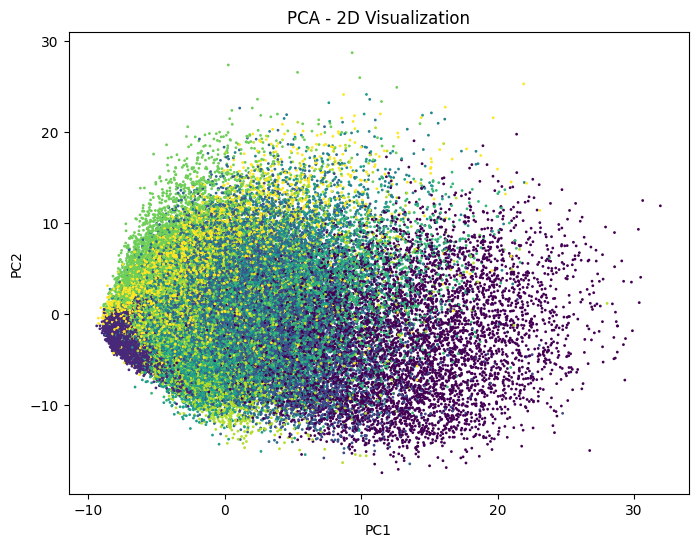

In [ ]:
# -------------------------------
# PCA Visualization
# -------------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y, s=1)
plt.title("PCA - 2D Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



t-SNE runtime: 81.12026643753052


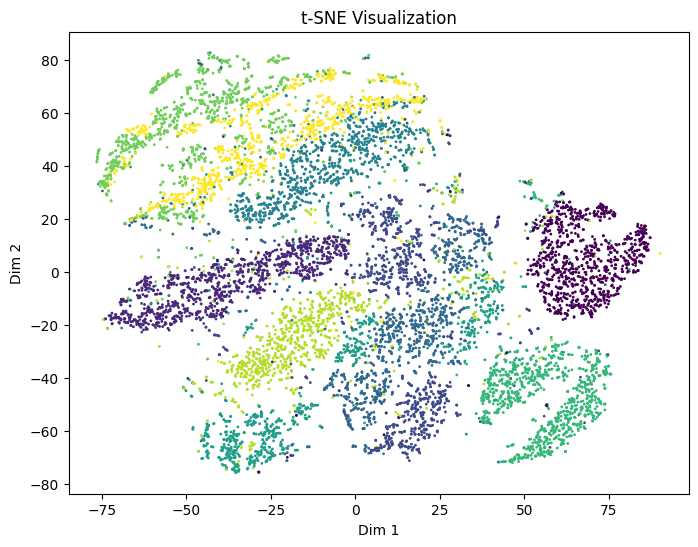

In [ ]:
# -------------------------------
# t-SNE (subset for speed)
# -------------------------------
subset_size = 10000
X_subset = X_scaled[:subset_size]
y_subset = y[:subset_size]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)

start = time.time()
X_tsne = tsne.fit_transform(X_subset)
print("t-SNE runtime:", time.time() - start)

# -------------------------------
# t-SNE Visualization
# -------------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_subset, s=1)
plt.title("t-SNE Visualization")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

The t-SNE algorithm took approximately 81.12 seconds to run, indicating its high computational cost. While it produces meaningful and well-separated visual clusters, its slower runtime makes it less suitable for large datasets compared to faster techniques like PCA.

In [ ]:
# -------------------------------
# Model Comparison
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Original data
start = time.time()
model_orig = LogisticRegression(max_iter=1000)
model_orig.fit(X_train, y_train)
pred_orig = model_orig.predict(X_test)
time_orig = time.time() - start

In [ ]:
# PCA-reduced data
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca_95, y, test_size=0.2, random_state=42
)

start = time.time()
model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train)
pred_pca = model_pca.predict(X_test_pca)
time_pca = time.time() - start

In [ ]:

# Results
print("\n--- Model Results ---")
print("Original Accuracy:", accuracy_score(y_test, pred_orig))
print("PCA Accuracy:", accuracy_score(y_test, pred_pca))
print("Original Time:", time_orig)
print("PCA Time:", time_pca)



--- Model Results ---
Original Accuracy: 0.9156428571428571
PCA Accuracy: 0.922
Original Time: 34.404022216796875
PCA Time: 36.96733117103577


The model trained on original data achieved 91.56% accuracy in 34.40 seconds, while the PCA-reduced model achieved slightly higher accuracy of 92.20% in 36.97 seconds. This indicates PCA helped improve prediction performance slightly, though it did not significantly reduce training time due to retained dimensional complexity.

Reflection

Through this project, I learned that PCA and t-SNE serve different but complementary purposes in dimensionality reduction. PCA focuses on preserving global variance and is computationally efficient, making it suitable for preprocessing and model training. In contrast, t-SNE emphasizes local structure and provides clearer visualization of clusters, though at a much higher computational cost. The results showed that even after reducing dimensions using PCA, the model maintained and slightly improved its accuracy, indicating that redundant or noisy features were removed. However, PCA still required many components to retain most of the variance, highlighting the complexity of the dataset. t-SNE produced more visually distinct groupings, but its slow runtime limits its use in large-scale applications. Overall, I learned that dimensionality reduction is a trade-off between efficiency and information loss, and the choice of method depends on whether the goal is visualization or improving model performance.

AI Assistance Statement

I used AI (ChatGPT) during this project to debug code errors, clarify concepts, and structure the analysis workflow. AI helped identify issues in PCA and t-SNE implementation, suggested improvements for visualization, and provided guidance on reflection and explanation, ensuring the notebook ran correctly and efficiently.

Conclusion

In conclusion, dimensionality reduction techniques like PCA and t-SNE are valuable for handling high-dimensional data. PCA improves efficiency and model performance, while t-SNE enhances visualization. Choosing the appropriate method depends on the task, balancing computational cost, interpretability, and the need to preserve important data patterns.